In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'D:\Data sceince\Library\pandas project guided\data\compressed_data.csv')

C:\Users\Anura\AppData\Local\Temp\ipykernel_11548\3213262384.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r'D:\Data sceince\Library\pandas project guided\data\compressed_data.csv')


In [3]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [5]:
df.isna().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [6]:
df.columns

Index(['id', 'NAME', 'host id', 'host_identity_verified', 'host name',
       'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country',
       'country code', 'instant_bookable', 'cancellation_policy', 'room type',
       'Construction year', 'price', 'service fee', 'minimum nights',
       'number of reviews', 'last review', 'reviews per month',
       'review rate number', 'calculated host listings count',
       'availability 365', 'house_rules', 'license'],
      dtype='object')

In [7]:
df['minimum nights'].isna().sum()

409

In [8]:
df.dropna(subset=['minimum nights'],inplace=True)

In [9]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df.dropna(subset=['price'],inplace=True)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Anura\AppData\Local\Temp\ipykernel_11548\3390950698.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)


In [10]:
df['price'].isnull().sum()

0

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 101943 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              101943 non-null  int64  
 1   NAME                            101702 non-null  object 
 2   host id                         101943 non-null  int64  
 3   host_identity_verified          101668 non-null  object 
 4   host name                       101544 non-null  object 
 5   neighbourhood group             101916 non-null  object 
 6   neighbourhood                   101929 non-null  object 
 7   lat                             101935 non-null  float64
 8   long                            101935 non-null  float64
 9   country                         101416 non-null  object 
 10  country code                    101825 non-null  object 
 11  instant_bookable                101851 non-null  object 
 12  cancellation_policy  

In [12]:
df['neighbourhood'].isnull().sum()

14

In [13]:
df.dropna(subset=['neighbourhood'], inplace=True)

In [14]:
df['neighbourhood'].isnull().sum()

0

In [15]:
df['neighbourhood group'].isnull().sum()

27

In [16]:
df.dropna(subset=['neighbourhood group'], inplace=True)

In [17]:
df['neighbourhood group'].isnull().sum()

0

In [18]:
df.duplicated().sum()

532

In [19]:
df.drop_duplicates(inplace=True)

In [20]:
df.duplicated().sum()

0

## Visualization

In [21]:
import seaborn as sns


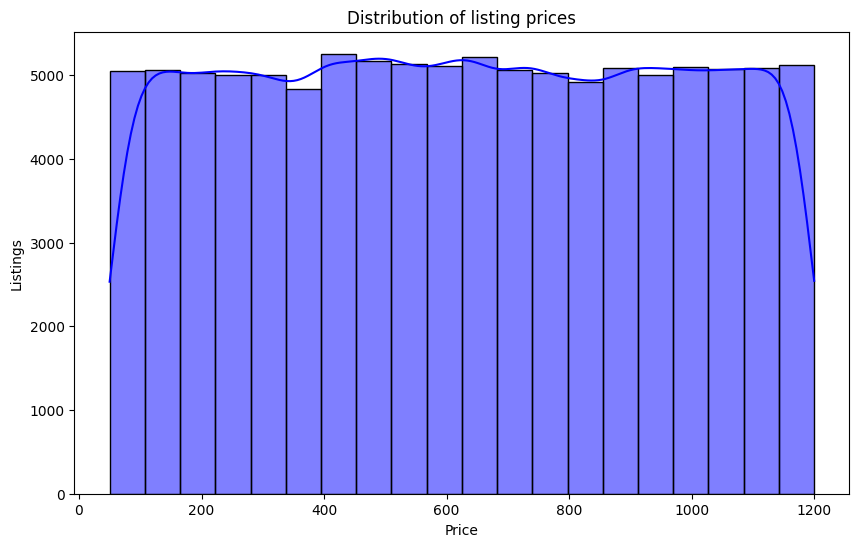

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'],bins=20, kde=True,color='blue')
plt.title('Distribution of listing prices')
plt.xlabel('Price')
plt.ylabel('Listings')
plt.savefig('../images/Distribution_of_listing_price.png')
plt.show()

### Insights
Listing prices are fairly distributed across different price ranges, with no single price band dominating heavily.


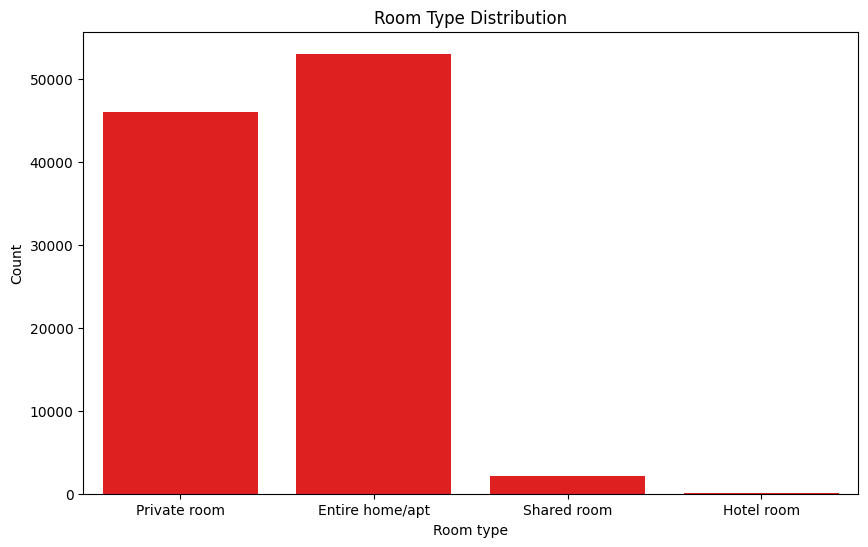

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(x = df['room type'],color='red')
plt.title('Room Type Distribution')
plt.xlabel('Room type')
plt.ylabel('Count')
plt.savefig('../images/Distribution_by_room_type.png')
plt.show()

### Insights
Entire home/apartment listings are the most common, indicating that customers likely prefer full-property stays over shared accommodations.
Hotel rooms are the least common room type in the dataset.

<>:13: SyntaxWarning: invalid escape sequence '\L'
<>:13: SyntaxWarning: invalid escape sequence '\L'
C:\Users\Anura\AppData\Local\Temp\ipykernel_11548\2140508430.py:13: SyntaxWarning: invalid escape sequence '\L'
  plt.savefig('../images/\Listings_by_neighbourhood Group.png')


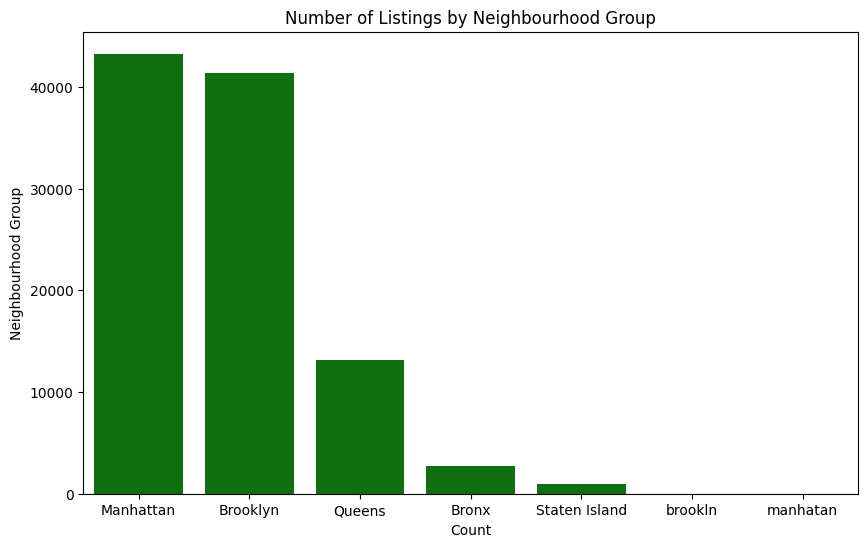

In [24]:
plt.figure(figsize=(10,6))

sns.countplot(
    x='neighbourhood group',
    data=df,
    color='green',
    order=df['neighbourhood group'].value_counts().index
)

plt.title('Number of Listings by Neighbourhood Group')
plt.xlabel('Count')
plt.ylabel('Neighbourhood Group')
plt.savefig('../images/\Listings_by_neighbourhood Group.png')
plt.show()

### Insights
Manhattan has the highest number of Airbnb listings, followed closely by Brooklyn.
Queens has significantly fewer listings compared to Manhattan and Brooklyn.
Bronx and Staten Island have the lowest Airbnb activity in the dataset.
This suggests that Airbnb demand and property concentration are heavily centered in Manhattan and Brooklyn.

C:\Users\Anura\AppData\Local\Temp\ipykernel_11548\1523505447.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'room type',y = 'price', data=df,palette='Set1')


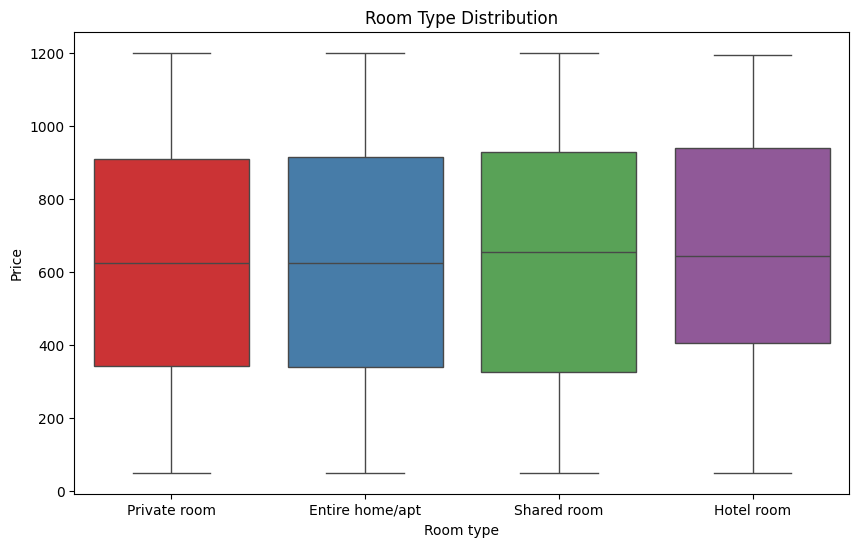

In [25]:
plt.figure(figsize=(10,6))
sns.boxplot(x = 'room type',y = 'price', data=df,palette='Set1')
plt.title('Room Type Distribution')
plt.xlabel('Room type')
plt.ylabel('Price')
plt.show()

### Insights
Price distributions across different room types are relatively similar overall.
However, hotel rooms tend to start at a comparatively higher price range, suggesting a slightly more premium pricing structure compared to other room types.

In [26]:
(df['minimum nights'] < 0).sum()

13

In [27]:
df.dropna(subset=['host_identity_verified'],inplace=True)

In [28]:
df['host_identity_verified'].isna().sum()

0

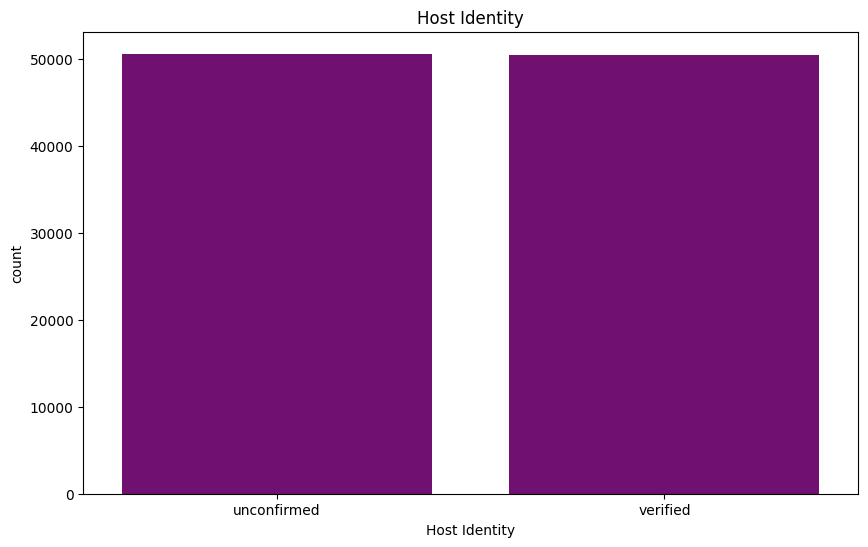

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(x = df['host_identity_verified'],color='purple')
plt.title('Host Identity')
plt.xlabel('Host Identity')
plt.ylabel('count')
plt.savefig('../images/Host_Identity.png')
plt.show()


### Insights
Verified and unconfirmed hosts are present in almost equal numbers on the platform.

Increasing host verification can help improve customer trust, platform credibility, and overall user confidence.


In [30]:
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Anura\AppData\Local\Temp\ipykernel_11548\3561184741.py:1: SyntaxWarning: invalid escape sequence '\$'
  df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)


In [31]:
df['service fee'].isna().sum()

238

In [32]:
df.dropna(subset=['service fee'],inplace=True)

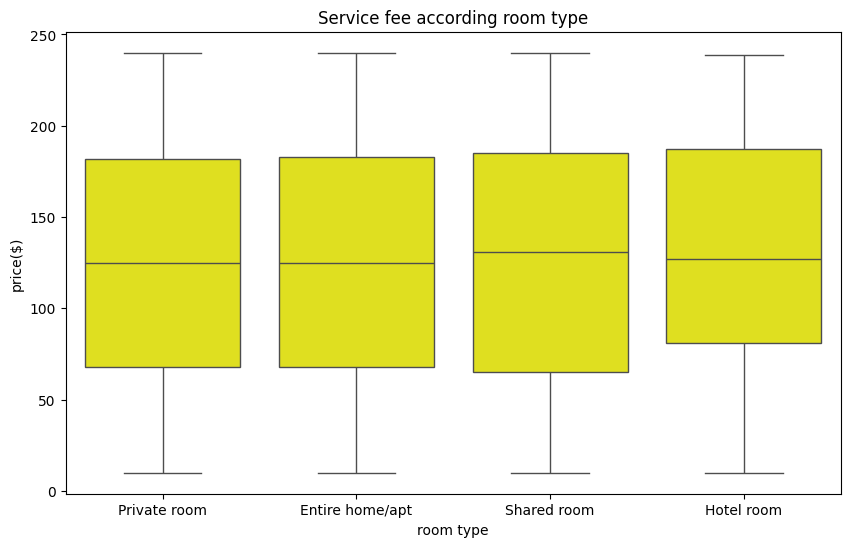

In [33]:
plt.figure(figsize=(10,6))
sns.boxplot(y = 'service fee',x = 'room type',data = df,color='yellow')
plt.title('Service fee according room type')
plt.xlabel('room type')
plt.ylabel('price($)')
plt.show()

### Insight
Service fee distributions are relatively similar across different room types.

However, hotel rooms and shared rooms appear to have slightly higher service fee ranges compared to other accommodation types.